# **Assignment 1: Demand prediction of bike sharing system**

Bike sharing services are nowadays spread all over the world. They are beneficial for cities as they offer a climate neutral and healthy way of transportation. Moreover, similar to e-scooters, for the companies and transportation researchers they generate valuable data. This includes the trip route, trip origins and destinations, duration, and much more.

In this assignment we use a public bike sharing dataset from Washington, D.C., USA. published by Fanaee-T, H. (2013). Bike Sharing [Dataset]. UCI Machine Learning Repository. https://doi.org/10.24432/C5W894.

## Your Task

Your task in this assignment is:

1) to predict the demand of hourly rentals (**target-column: cnt**) using the [XGBoost](https://xgboost.readthedocs.io/en/stable/) and linear regression model. In this notebook we have provided you with the basic structure how to approach the problem. Feel free to reuse and improve parts of the exercise material.

2) After you have created the model please upload your code to Github and post the link to the notebook in the corresponding forum for the assignment with a short text describing how you have solved the task.

## Load data

You can also find more information about the data and the columns at: https://archive.ics.uci.edu/dataset/275/bike+sharing+dataset

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

from xgboost import XGBRegressor

url = 'https://raw.githubusercontent.com/zhenliangma/Applied-AI-in-Transportation/master/Exercise_2_regression_model/Exercise2BikeSharing.csv'
df = pd.read_csv(url)

## Train / Test split
- Target: `cnt` (count of total rental bikes including both casual and registered)
- Predictors: weather (`temp`, `atemp`, `hum`, `windspeed`, `weathersit`), calendar (`hr`, `weekday`, `workingday`, `holiday`, `season`), and `yr`.
- We keep it simple; you can expand features (e.g., interactions) later.

In [2]:
# Dropping the colums i deem unneccessary and splitting data 80/20:
target = 'cnt'

X = df.drop(columns=[target,'casual','registered','dteday','instant','mnth'])
y = df[target].astype(float)

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)

## Data Processing / Feature Engineering

Before training the model think about data processing and feature engineering steps if applicable, such as:
- adding/removal of features
- normalization
- one hot encoding
- ...


In [7]:
# I already removed the features that i wanted to remove in the last step.
# I dont consider normalization of the columns to be neccessary as the ranges are quite similar.
# One hot encoding the categorical features and checking to see that the shapes make sense:

categorical_features = ['season', 'hr', 'weekday', 'weathersit']

preprocessor = ColumnTransformer(transformers=[('cat',OneHotEncoder(drop='first', handle_unknown='ignore'),categorical_features)],remainder='passthrough')

X_train_encoded = preprocessor.fit_transform(X_train)
X_test_encoded = preprocessor.transform(X_test)

X_train_encoded.shape, X_test_encoded.shape

((13903, 42), (3476, 42))

## Hyperparameter optimization
Hyperparameter tuning helps find the best set of hyperparameters for your model. Use Grid Search or Random Search with Cross Validation from scikit-learn to search for the best combination of parameters.

In [14]:
xgb = XGBRegressor(random_state=42,objective='reg:squarederror')

param_grid = {'n_estimators': [200, 300, 500], 'max_depth': [3, 5, 7], 'learning_rate': [0.05, 0.1, 0.2]}

grid_search = GridSearchCV(estimator=xgb,param_grid=param_grid,cv=5,scoring='neg_mean_squared_error',n_jobs=-1)
grid_search.fit(X_train_encoded, y_train)

print(grid_search.best_params_)
print(grid_search.best_score_)

{'learning_rate': 0.2, 'max_depth': 5, 'n_estimators': 500}
-2523.07030564257


## Train the XGBoost and Linear regression models
Now, create an XGBoost and linear regression model using the best parameters and train them using the training data.

In [15]:
xgb_model = grid_search.best_estimator_

linear_model = LinearRegression()

linear_model.fit(X_train_encoded, y_train)

LinearRegression()

## Make predictions
Use the trained models to make predictions on the test data and compare the performance of the XGBoost and linear regression models using metrics like Mean Squared Error (MSE) and R-squared.

In [16]:
y_pred_xgb = xgb_model.predict(X_test_encoded)
y_pred_linear = linear_model.predict(X_test_encoded)

xgb_mse = mean_squared_error(y_test, y_pred_xgb)
xgb_r2 = r2_score(y_test, y_pred_xgb)

linear_mse = mean_squared_error(y_test, y_pred_linear)
linear_r2 = r2_score(y_test, y_pred_linear)

print("XGBoost")
print("MSE:", xgb_mse)
print("R2:", xgb_r2)
print("")
print("Linear regression")
print("MSE:", linear_mse)
print("R2:", linear_r2)

XGBoost
MSE: 2305.296555699564
R2: 0.9271982753925115

Linear regression
MSE: 10184.579272444009
R2: 0.6783689570860432


## Visualize the predictions and compare the mdoels
Create a "Actual vs. Predicted Values" graph to give a visual inspection of the prediction quality.

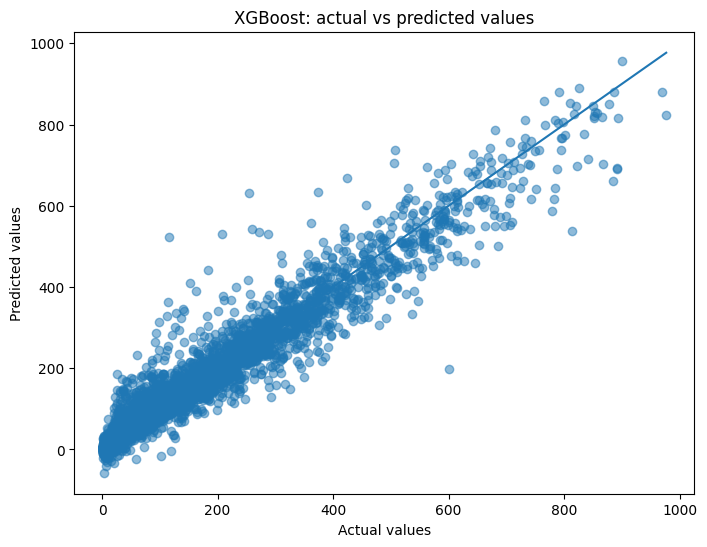

In [17]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred_xgb, alpha=0.5)
plt.plot([y_test.min(), y_test.max()],[y_test.min(), y_test.max()])
plt.xlabel('Actual values')
plt.ylabel('Predicted values')
plt.title('XGBoost: actual vs predicted values')
plt.show()

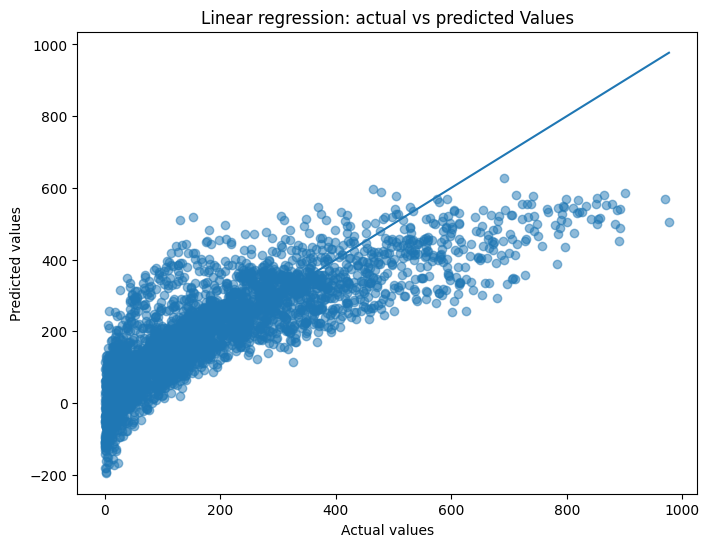

In [14]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred_linear, alpha=0.5)
plt.plot([y_test.min(), y_test.max()],[y_test.min(), y_test.max()])
plt.xlabel('Actual values')
plt.ylabel('Predicted values')
plt.title('Linear regression: actual vs predicted Values')
plt.show()